In [9]:
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.datasets import make_regression

In [3]:
X, y = make_regression(n_samples=100, n_features=1,
                      n_informative=1, noise=10, random_state=42)

In [4]:
def normal_equation(X, y):
    x_transpose = np.transpose(X)
    x_transpose_x = np.dot(x_transpose, X)
    x_transpose_y = np.dot(x_transpose, y)

    try:
        theta = np.linalg.solve(x_transpose_x, x_transpose_y)
        return theta
    except np.linalg.LinAlgError:
        return None

In [5]:
x_with_intercept = np.c_[np.ones((X.shape[0], 1)), X]
theta = normal_equation(x_with_intercept, y)
if theta is not None:
    print(theta)
else:
    print("unable to compute theta.")

[ 1.16511532 44.43716999]


#### Predict on New Test Data Instances




In [7]:
def predict(X, theta):
    predictions = np.dot(X, theta)
    return predictions

In [8]:
X_test = np.array([[1], [4]])
X_test_with_intercept = np.c_[np.ones((X_test.shape[0], 1)), X_test]
predictions = predict(X_test_with_intercept, theta)
print("Predictions:", predictions)

Predictions: [ 45.60228531 178.91379529]


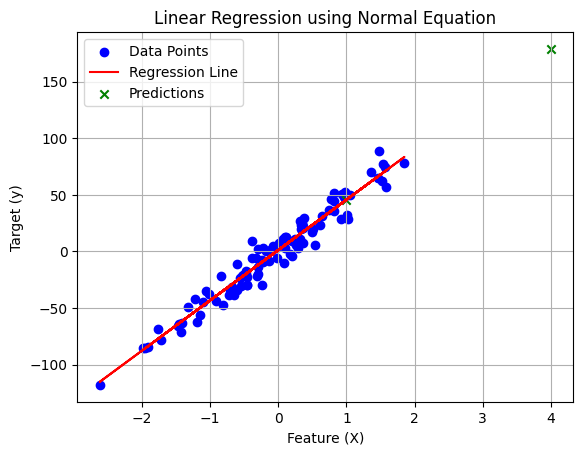

In [11]:
plt.scatter(X, y, color='blue', label='Data Points')  # Plot the original data points
plt.plot(X, predict(x_with_intercept, theta), color='red', label='Regression Line')  # Plot the regression line
plt.scatter(X_test, predictions, color='green', marker='x', label='Predictions')  # Plot the predictions
plt.title('Linear Regression using Normal Equation')
plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')
plt.legend()
plt.grid()
plt.show()